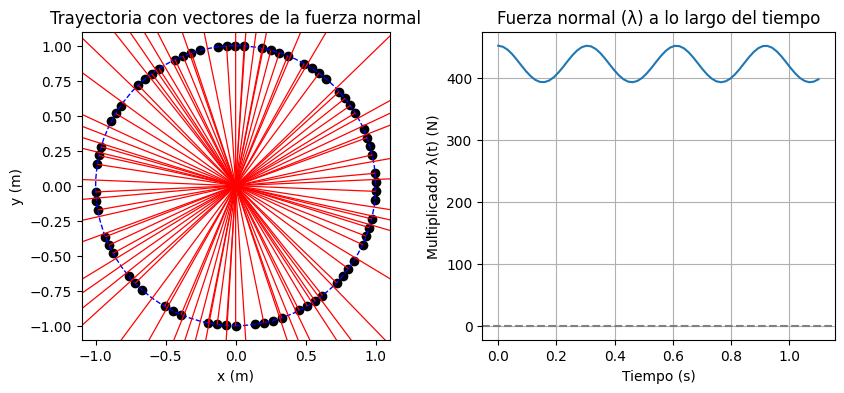

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parámetros físicos
g = 9.81     # gravedad (m/s^2)
R = 1.0      # radio de la pista (m)
m = 1.0      # masa de la partícula (kg)

# Condiciones iniciales (parte inferior del círculo)
theta0 = -np.pi/2     # ángulo inicial
omega0 = 3*np.sqrt(5*g/R)
#omega0 = 0.1
# Velocidad angular critica
#omega0 = np.sqrt(5*g/R)     # velocidad angular inicial (menor que la crítica)
y0 = [theta0, omega0]

# Ecuaciones del movimiento
def ecuaciones(y, t, g, R):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -(g / R) * np.cos(theta)
    return [dtheta_dt, domega_dt]

# Tiempo de integración
t = np.linspace(0, 1.1, 70)

# Resolver con odeint
sol = odeint(ecuaciones, y0, t, args=(g, R))
theta = sol[:, 0]
omega = sol[:, 1]

# Calcular lambda(t)
lambda_vals = (m / (2 * R)) * (R * omega**2 - g * np.sin(theta)) * (2*R) # Debido al dos del multiplicador

# Coordenadas cartesianas
x = R * np.cos(theta)
y = R * np.sin(theta)

# --- Dibujar trayectoria con vectores de fuerza normal ---

# Selección de puntos para mostrar vectores (por claridad)
num_arrows = 50
indices = np.linspace(0, len(t) - 1, num_arrows, dtype=int)

# Componentes de la fuerza normal: -λ * (x̂, ŷ)
normals_x = -lambda_vals[indices] * x[indices] / R
normals_y = -lambda_vals[indices] * y[indices] / R

# Escalado visual
scale = 0.02


fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(121)
ax.scatter(x, y, color='k' ,label="Trayectoria")
circle = plt.Circle((0, 0), R, color='b', fill=False, linestyle='--', label="Pista circular")
ax.add_patch(circle)

ax1 = fig.add_subplot(122)
ax1.plot(t, lambda_vals, label="λ(t)")
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Multiplicador λ(t) (N)")
ax1.set_title("Fuerza normal (λ) a lo largo del tiempo")
ax1.grid(True)

# Vectores normales (fuerza de restricción)
ax.quiver(
    x[indices], y[indices],
    normals_x, normals_y,
    angles='xy', scale_units='xy', scale=1/scale,
    color='red', width=0.004, label='Fuerza normal (−λ ∇f)'
)

ax.set_aspect('equal')
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Trayectoria con vectores de la fuerza normal")
#ax.legend()
plt.show()